In [22]:
import pandas as pd
import os,torch,collections
import numpy as np
#go through formual mask ious in overlap/ and record how ovvverlap changes across iters for each pruning
root="/workspace/CCE_NLI/BERT/overlap/lottery_ticket/Run0.25"


#if root=wanda
c1=pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
c2=pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
c3=pd.read_csv("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']


active_neuron_per_cluster=[c1,c2,c3]
def convert(x):
    if isinstance(x, str) and x.startswith('tensor'):
        # Remove 'torch.tensor(' and ')' to get the list
        tensor_str = x[7:-1]
        return torch.tensor(eval(tensor_str)).item()
    elif isinstance(x, str):
        # If the entry is a number (int or float), convert it to a tensor
        return float(x)
    else:
        # If the entry is already a tensor, return it as is
        return x
from sortedcontainers import SortedDict
pruned_percents=[0.0, 0.25, 0.44, 0.58, 0.68, 0.76]

def get_aligments(root, active_neuron_per_cluster, keep_original=False):
    stored_alignments=collections.defaultdict(lambda : collections.defaultdict())
    for cluster in os.listdir(os.path.join(root)):
        if '.ipynb_checkpoints' in cluster: continue
        for alignment in os.listdir(os.path.join(root, cluster)):
            #if '_between' in alignment: continue
            if alignment == '.ipynb_checkpoints': continue
            file = os.path.join(root, cluster, alignment)
            
            overlap_file = pd.read_csv(file)
            overlap_file['iou'] = overlap_file['iou'].apply(lambda x: convert(x))
            overlap_file['neuron']= overlap_file['neuron'].apply(lambda x: int(x))
            
            active_neurons = {}
            for neuron, iou in zip(overlap_file[overlap_file['iou'] >0]['neuron'], overlap_file[overlap_file['iou'] >0]['iou']):
                active_neurons[neuron] = np.round(iou,3)
            for neuron in active_neuron_per_cluster[int(cluster[7:])-1]:
                if neuron not in active_neurons:
                    active_neurons[neuron] = 0
         
            try:
                pruning_iter = int(alignment[:alignment.index('I')])  #this for alignment with orig
            except:
                continue
            if not keep_original: 
                if pruning_iter==0.0:continue
            stored_alignments[pruned_percents[pruning_iter]*100][cluster] = SortedDict(active_neurons)
    return stored_alignments
    

        
    

#get all neurons in 0% pruning
#go to all other files:
#stored_alignments=get_aligments(root, active_neuron_per_cluster)

In [23]:
import matplotlib.pyplot as plt
def plot(root, alignment_changes, axs, i, j):
    """
    Add a subplot at position (i, j) to an existing axs grid.

    Parameters:
    - root: str, title for the plot
    - alignment_changes: tuple of (c1, c2, c3) dictionaries
    - axs: 2D array of Axes (from plt.subplots)
    - i, j: indices for the subplot position
    """
    alignment_change_c1, alignment_change_c2, alignment_change_c3 = alignment_changes

    # Define colors and markers
    colors = {'c1': 'blue', 'c2': 'orange', 'c3': 'green'}
    markers = {'c1': 'o', 'c2': 's', 'c3': '^'}

    ax = axs[i][j] if axs.ndim == 2 else axs[i * axs.shape[1] + j]  # supports both 1D/2D

    ax.plot(list(alignment_change_c1.keys()), list(alignment_change_c1.values()),
            label='Cluster 1', marker=markers['c1'], color=colors['c1'])

    ax.plot(list(alignment_change_c2.keys()), list(alignment_change_c2.values()),
            label='Cluster 2', marker=markers['c2'], color=colors['c2'])

    ax.plot(list(alignment_change_c3.keys()), list(alignment_change_c3.values()),
            label='Cluster 3', marker=markers['c3'], color=colors['c3'])

    ax.set_xlabel('Pruned %')
    ax.set_ylabel('Overlap')
    ax.set_title(f'{root}')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.margins(x=0.05)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)



In [24]:
def get_avg_alignment(stored_alignments):
    alignment_change_c1={}
    min_change_c1={}
    max_change_c1 ={}
    for per in sorted(stored_alignments.keys()):
        #print(per, stored_alignments[per].keys())
        if f'Cluster1' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster1'].values())
            o=ious[:]
            
            ious = [iou for iou in ious if iou > 0]
            if len(ious)==0:
                avg=0
                min_=0
                max_=0
            else:
                avg = sum(ious)/len(ious)
                min_ = min([x for x in ious if x != 0])
                max_ = max(ious)
        else:
            avg=0
        alignment_change_c1[per] = avg
        min_change_c1[per] = min_
        max_change_c1[per] = max_
 

    alignment_change_c2={}
    min_change_c2={}
    max_change_c2 ={}
    for per in sorted(stored_alignments.keys()):
        if f'Cluster2' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster2'].values())
         
            ious = [iou for iou in ious if iou > 0]
            if len(ious)==0:
                avg=0
                min_=0
                max_=0
            else:
                avg = sum(ious)/len(ious)
                min_ = min([x for x in ious if x != 0])
                max_ = max(ious)
        else:
            avg=0
        alignment_change_c2[per] = avg
        min_change_c2[per] = min_
        max_change_c2[per] = max_

    alignment_change_c3={}
    min_change_c3={}
    max_change_c3={}
    for per in sorted(stored_alignments.keys()):
        if f'Cluster3' in stored_alignments[per].keys():
            ious= list(stored_alignments[per][f'Cluster3'].values())
            ious = [iou for iou in ious if iou > 0]
  
            if len(ious)==0:
                avg=0
                min_=0
                max_=0
            else:
                avg = sum(ious)/len(ious)
                min_ = min([x for x in ious if x != 0])
                max_ = max(ious)
            alignment_change_c3[per] = avg
            min_change_c3[per] = min_
            max_change_c3[per] = max_
            
            
    align_changes = [alignment_change_c1, alignment_change_c2, alignment_change_c3]
    min_changes = [min_change_c1, min_change_c2, min_change_c3]
    max_changes = [max_change_c1, max_change_c2, max_change_c3]
    print(align_changes)
    return align_changes, min_changes, max_changes

BERT lottery_ticket
[{25.0: 0.8290000000000003, 44.0: 0.8304277343750004, 57.99999999999999: 0.8312519531250004, 68.0: 0.8223349609374991, 76.0: 0.8213378906250003}, {25.0: 0.5811621093750003, 44.0: 0.5742548828125003, 57.99999999999999: 0.5741386718749995, 68.0: 0.5463408203125, 76.0: 0.5465595703124996}, {25.0: 0.34832975460122706, 44.0: 0.3401996996996996, 57.99999999999999: 0.3089433139534885, 68.0: 0.28994375000000033, 76.0: 0.27580418535127044}]
BERT wanda
[{25.0: 0.9228173828125003, 44.0: 0.8984882812499989, 57.99999999999999: 0.8747265625000008, 68.0: 0.8594316406249994, 76.0: 0.8493095703124997}, {25.0: 0.8437861328124998, 44.0: 0.7811943359375, 57.99999999999999: 0.7258583984375001, 68.0: 0.6885615234374997, 76.0: 0.6401845703125005}, {25.0: 0.7649088397790063, 44.0: 0.6755961272475797, 57.99999999999999: 0.592, 68.0: 0.5415952712100135, 76.0: 0.49921793103448314}]
BOWMAN lottery_ticket
[{25.0: 0, 44.0: 0.12, 57.99999999999999: 0, 68.0: 0, 76.0: 0}, {25.0: 0, 44.0: 0, 57.9999

/tmp/ipykernel_3367/3406450727.py:50: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6, wspace=0.3)  # vertical and horizontal gaps


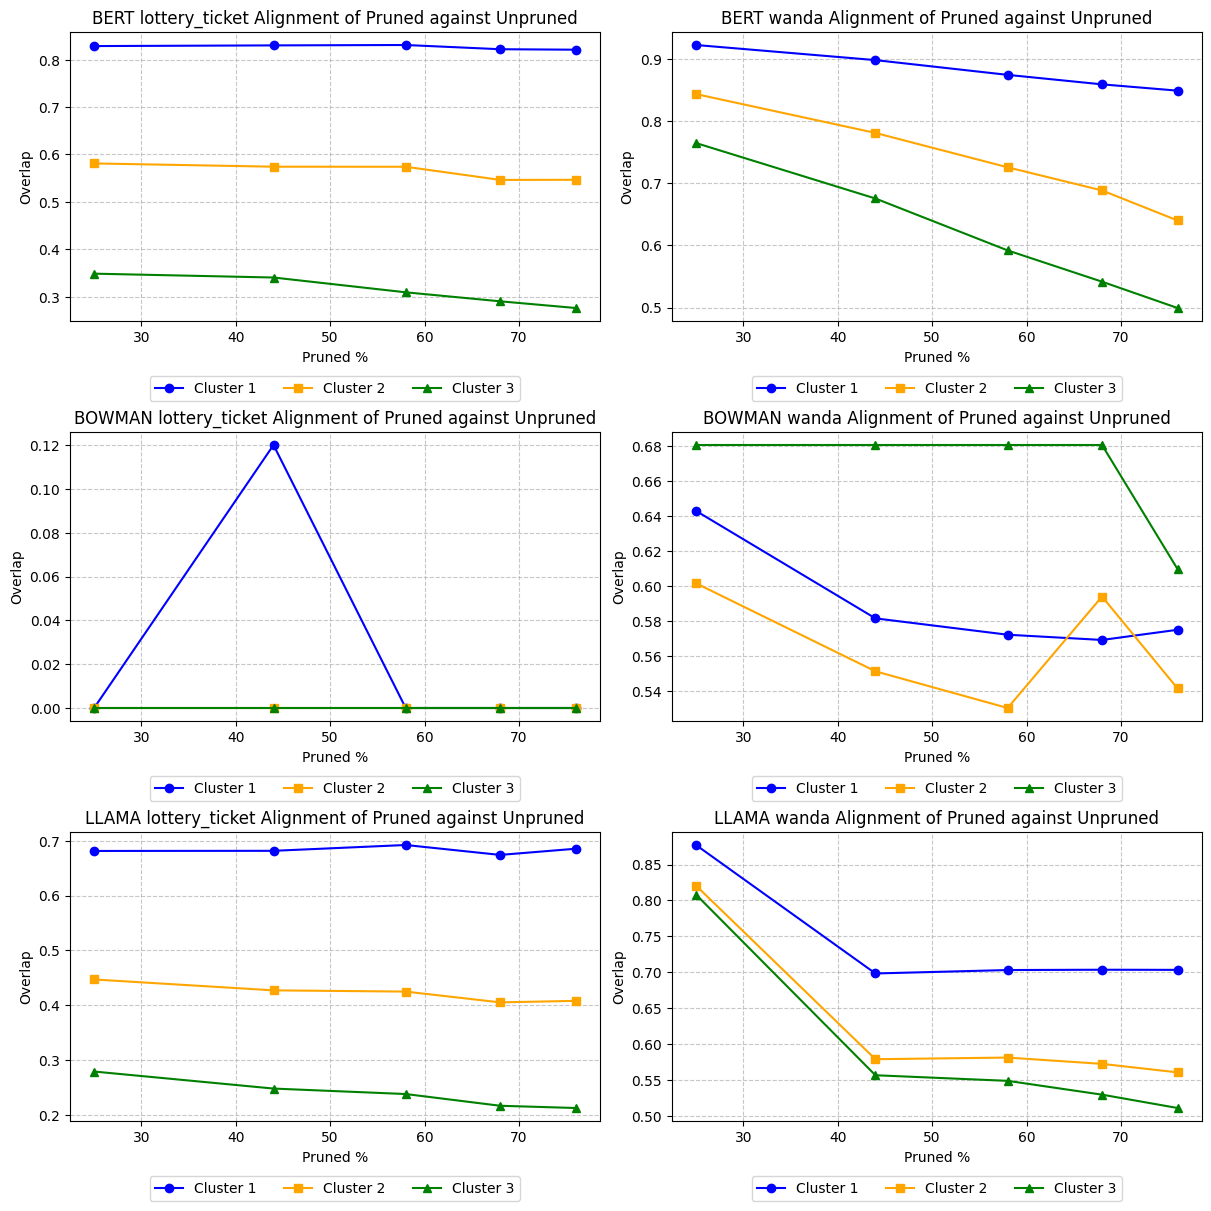

In [40]:


import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(12, 12),constrained_layout=True)

for k,model in enumerate(['BERT', 'BOWMAN', 'LLAMA']):
    for j,method in enumerate(['lottery_ticket', 'wanda']):
        alignment_changes = []
        try:
            root = f'/workspace/CCE_NLI/{model}/overlap/{method}/overlap_with_original/Run0.25'
            #for cluster in os.listdir(root):
            if '.ipy' in root: continue
            path = root

            c1=pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Run0.25/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
            c2=pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Run0.25/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
            c3=pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Run0.25/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']

            print(model, method)
            active_neuron_per_cluster=[c1,c2,c3]
        
            stored_alignments=get_aligments(path, active_neuron_per_cluster)
            alignment_change, min_changes, max_changes = get_avg_alignment(stored_alignments)

            if alignment_changes:
                for i in range(len(alignment_change)):
                    temp={}
                    for prunepercent, align in alignment_changes[-1][i].items():
                        if prunepercent==0.0: continue
                        temp[prunepercent] = align + alignment_change[i][prunepercent]
                    alignment_changes[-1][i] = temp
            else:
                change=[]
                for i,cluster in enumerate(alignment_change):
                    
                    change.append(cluster)
                alignment_changes.append(change)


            for i,cluster in enumerate(alignment_changes[0]):
                for percent, comb in cluster.items():
                    

                    alignment_changes[0][i][percent] = comb
            
            avergae_alignment = alignment_changes[0]
            plot(f"{model} {method} Alignment of Pruned against Unpruned", avergae_alignment, axs, k, j)
        except Exception as e:
            print(f"Skipping {model}_{method} because {e}")

plt.subplots_adjust(hspace=0.6, wspace=0.3)  # vertical and horizontal gaps

BERT lottery_ticket
[{0.0: 0.6733291272344892, 25.0: 0.675939011566771, 44.0: 0.6853638275499478, 57.99999999999999: 0.6867034700315462, 68.0: 0.6833848580441647, 76.0: 0.6851650893796009}, {0.0: 0.3978794084186575, 25.0: 0.3948919226393632, 44.0: 0.41507167235494896, 57.99999999999999: 0.4114311717861205, 68.0: 0.40514448236632533, 76.0: 0.4073538111490326}, {0.0: 0.08481038374717839, 25.0: 0.08818013856812938, 44.0: 0.08693791574279379, 57.99999999999999: 0.08622107438016527, 68.0: 0.08943280182232345, 76.0: 0.08978418803418804}]
BERT wanda
[{0.0: 0.5317849624060149, 25.0: 0.5329714285714287, 44.0: 0.5322676691729322, 57.99999999999999: 0.5327999999999997, 68.0: 0.5323022556390974, 76.0: 0.5308270676691731}, {0.0: 0.4706470588235291, 25.0: 0.4717774244833071, 44.0: 0.4772289348171706, 57.99999999999999: 0.47699682034976154, 68.0: 0.4803847376788551, 76.0: 0.48128934817170094}, {0.0: 0.09664999999999999, 25.0: 0.09627577937649885, 44.0: 0.09877619047619056, 57.99999999999999: 0.096088

/tmp/ipykernel_3367/2540428863.py:46: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6, wspace=0.3)  # vertical and horizontal gaps


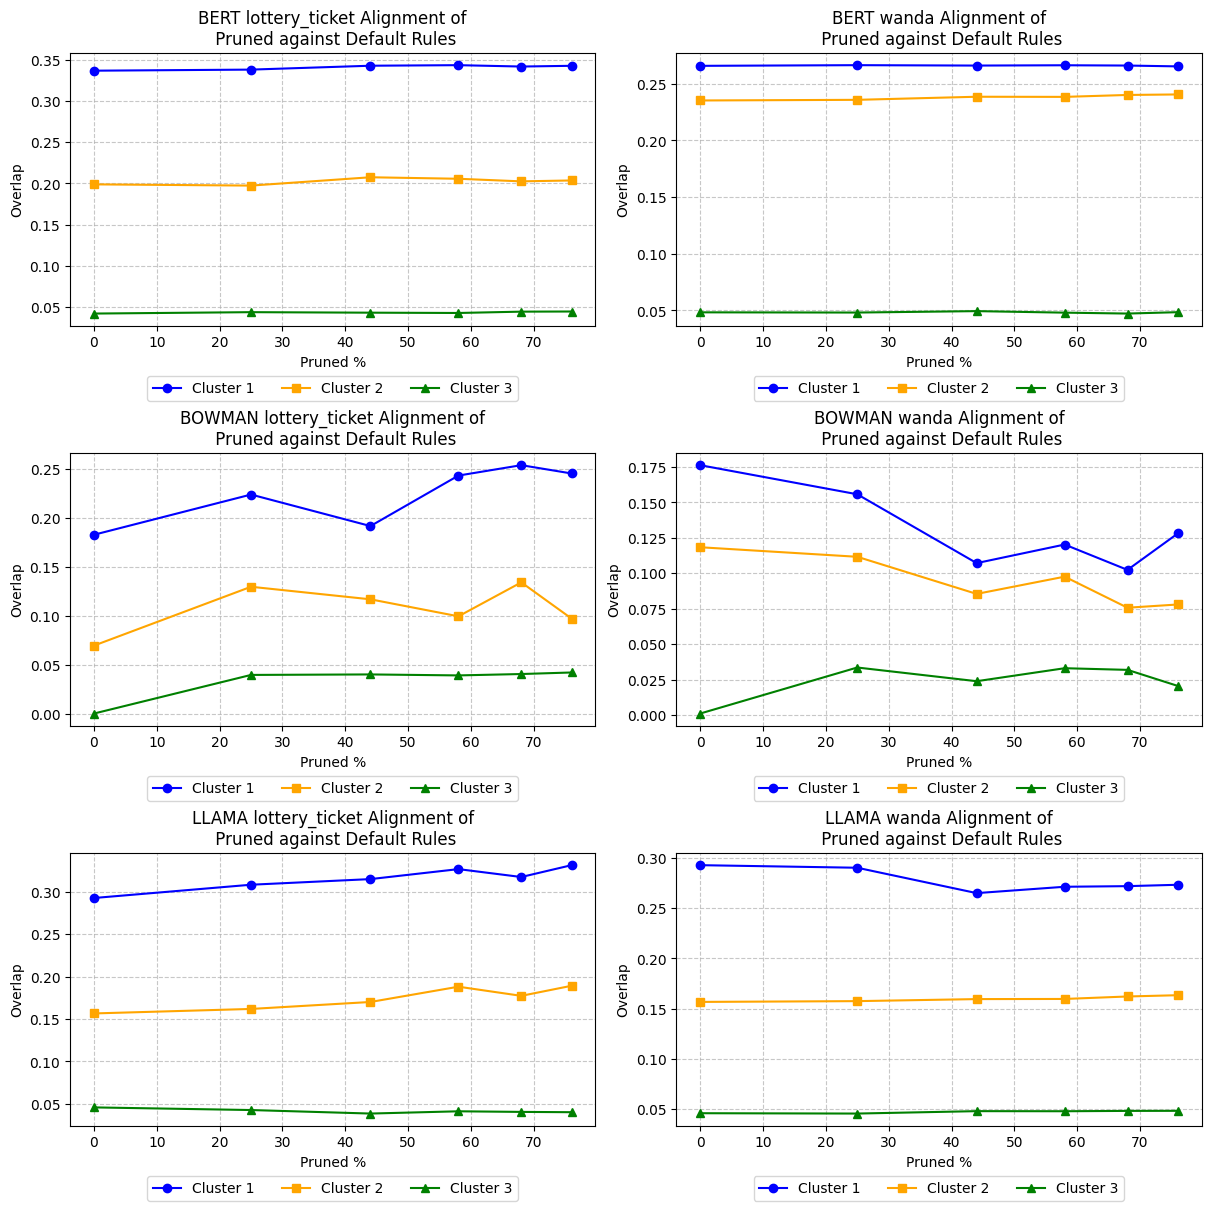

In [41]:


import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(12, 12),constrained_layout=True)

for k,model in enumerate(['BERT', 'BOWMAN', 'LLAMA']):
    for j,method in enumerate(['lottery_ticket', 'wanda']):
        alignment_changes = []
        try:
            root = f'/workspace/CCE_NLI/{model}/overlap/{method}/overlap_w_pretrained/Run0.25'
            #for cluster in os.listdir(root):
            if '.ipy' in root: continue
            path = root

            c1=pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Run0.25/Expls/0.0%Pruned/Cluster1IOUS1024N.csv")['unit']
            c2=pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Run0.25/Expls/0.0%Pruned/Cluster2IOUS1024N.csv")['unit']
            c3=pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Run0.25/Expls/0.0%Pruned/Cluster3IOUS1024N.csv")['unit']

            print(model, method)
            active_neuron_per_cluster=[c1,c2,c3]
        
            stored_alignments=get_aligments(path, active_neuron_per_cluster, keep_original=True)
            alignment_change, min_changes, max_changes = get_avg_alignment(stored_alignments)

            if alignment_changes:
                for i in range(len(alignment_change)):
                    temp={}
                    for prunepercent, align in alignment_changes[-1][i].items():
                        temp[prunepercent] = align + alignment_change[i][prunepercent]
                    alignment_changes[-1][i] = temp
            else:
                change=[]
                for i,cluster in enumerate(alignment_change):
                    change.append(cluster)
                alignment_changes.append(change)


            for i,cluster in enumerate(alignment_changes[0]):
                for percent, comb in cluster.items():

                    alignment_changes[0][i][percent] = comb/2
            avergae_alignment = alignment_changes[0]
            plot(f"{model} {method} Alignment of\n Pruned against Default Rules", avergae_alignment, axs, k, j)
        except Exception as e:
            print(f"Skipping {model}_{method} because {e}")

plt.subplots_adjust(hspace=0.6, wspace=0.3)  # vertical and horizontal gaps

In [68]:
ious=list(stored_alignments[89.2626953125]['Cluster3'].values())
sum(ious)/len(ious)

0.05557738095238089

In [34]:
ious=list(pd.read_csv("/workspace/CCE_NLI/BERT/overlap/lottery_ticket/Run3/Cluster2/Alignment_between_pruning_iteration_0_and_random.csv")['iou'])

In [39]:
ious = [convert(iou) for iou in ious]

In [42]:
sum(ious)/len(ious)

0.3046840819661156